# 03. Recommendation Systems and Ranking

Recommendation systems are causal systems hiding inside machine learning systems.

A recommender does not merely predict what a user likes. It changes what the user sees, clicks, buys, watches, saves, and returns to later. That means offline metrics based on historical clicks can be deeply misleading:

- popular items get more exposure, so they get more clicks,
- top-ranked items get more attention, so they look more relevant,
- the production policy decides what data exists,
- unexposed items have missing outcomes,
- a new ranking policy may put users into contexts that the old policy rarely explored.

This notebook turns recommendation and ranking into causal decision problems. We will simulate logged recommendation data, estimate policy value using off-policy evaluation, diagnose support and position bias, and design a professional readout for whether a new ranking policy is ready for an online test.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why recommender feedback is logged under a behavior policy.
- Define policy value for recommendations and rankings.
- Distinguish prediction metrics from causal policy metrics.
- Estimate a new recommender policy offline using IPS, SNIPS, and doubly robust estimators.
- Diagnose common support and effective sample size problems.
- Explain position bias and inverse examination weighting.
- Identify feedback loops created by exposure-based learning.
- Translate offline causal evidence into an A/B test decision memo.

## 1. Setup

We will use numpy, pandas, sklearn, statsmodels, seaborn, and Graphviz.

In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings

warnings.filterwarnings("ignore")

from IPython.display import Markdown, display
from graphviz import Digraph
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import softmax, expit
from scipy.stats import norm
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


rng = np.random.default_rng(20260430)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 130


def pct(x, digits=1):
    """Compute pct for the recommendation systems and ranking example.
    
    Inputs:
    - `x`: numeric input, variable, or node name used by the helper function.
    - `digits`: number of decimal places used for formatted display.
    Returns: a percentage-formatted string for display tables."""
    return f"{100 * x:.{digits}f}%"


def dollars(x, digits=0):
    """Compute dollars for the recommendation systems and ranking example.
    
    Inputs:
    - `x`: numeric input, variable, or node name used by the helper function.
    - `digits`: number of decimal places used for formatted display.
    Returns: a currency-formatted string for display tables."""
    return f"${x:,.{digits}f}"


def styled_table(df, pct_cols=None, money_cols=None, num_cols=None):
    """Compute styled table for the recommendation systems and ranking example.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `pct_cols`: columns that should be formatted as percentages.
    - `money_cols`: columns that should be formatted as monetary amounts.
    - `num_cols`: columns that should be formatted as ordinary numeric values.
    Returns: a styled pandas table for compact notebook display."""
    pct_cols = pct_cols or []
    money_cols = money_cols or []
    num_cols = num_cols or []

    fmt = {}
    for col in pct_cols:
        fmt[col] = lambda v: pct(v, 2)
    for col in money_cols:
        fmt[col] = lambda v: dollars(v, 2) if abs(v) < 100 else dollars(v, 0)
    for col in num_cols:
        fmt[col] = lambda v: f"{v:,.3f}"
    return df.style.format(fmt)

### Dataset and Experiment Setup

This notebook simulates recommendation and ranking data. The units include users, items, impressions, ranked positions, and search or recommendation sessions. The treatment can be exposure, position, ranking policy, or a recommendation algorithm. Outcomes include clicks, rewards, purchases, or engagement. The examples also include logged ranking policies and feedback loops.

The data is synthetic because recommendation systems create severe counterfactual problems. We observe clicks only for items that were shown and often only under the ranking policy that produced the exposure. The notebook therefore generates item relevance, user context, position effects, logged exposure, and hidden counterfactual rewards. This lets the reader see why observed clicks are not pure preferences, why position bias matters, why logged propensities are useful, and why feedback loops can make a system appear to improve while narrowing what it learns from.


## 2. The Causal Question in Recommendation

A supervised recommender asks:

> Which item is the user likely to click, given historical data?

A causal recommender asks:

> What reward would the user generate if we showed a different item or ranking?

For a single recommendation slot, let $A_i$ be the item shown to user-context $X_i$ and let $Y_i(a)$ be the reward if item $a$ were shown. The value of a policy $\pi$ is:

$$
V(\pi) = E\left[\sum_{a} \pi(a\mid X)Y(a)\right]
$$

For a deterministic policy that always chooses one item:

$$
V(\pi) = E[Y(\pi(X))]
$$

The difficulty is that logged data contains only:

$$
Y_i = Y_i(A_i)
$$

We do not observe what would have happened for items that were not shown. This is the same fundamental problem of causal inference, now inside a recommender system.

## 3. Why Historical Clicks Are Biased

The production recommender is the data-generating process. If it mostly shows popular items, the data will mostly contain outcomes for popular items. If it rarely shows new items, the data will contain little evidence about new items.

This creates several biases:

- **Selection bias:** only shown items have observed outcomes.
- **Position bias:** top-ranked items are more likely to be examined and clicked.
- **Popularity bias:** old winners get more exposure and therefore more feedback.
- **Trust bias:** users may click top results because they trust the system.
- **Support failure:** a target policy may choose actions rarely or never chosen by the logging policy.

Counterfactual learning-to-rank work studies how to learn from biased interaction logs. Jagerman and de Rijke (2020) describe position bias as users observing and clicking top-ranked items more than lower-ranked ones. Vardasbi, Oosterhuis, and de Rijke (2020) emphasize that clicks can be biased by position, selection, and trust, so click probability is not the same as relevance probability.

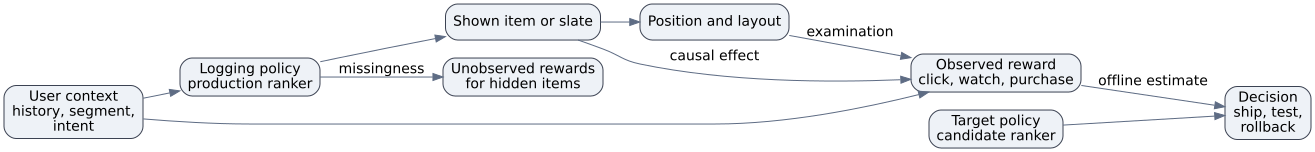

In [2]:
dot = Digraph("recsys_causal_graph", format="svg")
dot.attr(rankdir="LR", bgcolor="transparent")
dot.attr("node", shape="box", style="rounded,filled", color="#3B4252", fillcolor="#EEF2F7", fontname="DejaVu Sans")
dot.attr("edge", color="#5E6C84", fontname="DejaVu Sans")

dot.node("context", "User context\nhistory, segment,\nintent")
dot.node("policy", "Logging policy\nproduction ranker")
dot.node("shown", "Shown item or slate")
dot.node("position", "Position and layout")
dot.node("reward", "Observed reward\nclick, watch, purchase")
dot.node("unobserved", "Unobserved rewards\nfor hidden items")
dot.node("newpolicy", "Target policy\ncandidate ranker")
dot.node("decision", "Decision\nship, test,\nrollback")

dot.edge("context", "policy")
dot.edge("policy", "shown")
dot.edge("context", "reward")
dot.edge("shown", "reward", label="causal effect")
dot.edge("position", "reward", label="examination")
dot.edge("shown", "position")
dot.edge("policy", "unobserved", label="missingness")
dot.edge("newpolicy", "decision")
dot.edge("reward", "decision", label="offline estimate")

dot

Off-policy evaluation (OPE) formalizes this problem. Su, Dimakopoulou, and Krishnamurthy (2019) describe the key OPE challenge as distribution mismatch between the target policy and the logging policy. Saito and Joachims (2022) note that recommender systems often have large action spaces, which can make support and variance problems severe.

## 4. Running Example: Logged Top-Slot Recommendations

We will simulate an e-commerce recommender that chooses one item for the top recommendation slot.

Each impression has:

- user segment,
- user price sensitivity,
- user novelty preference,
- item category,
- item popularity,
- item margin,
- the item shown by the production logging policy,
- the logging propensity for that item,
- observed click/purchase reward.

Because this is a simulation, we also know the true expected reward for every possible item. In real data, those counterfactual rewards are hidden.

In [3]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def make_catalog(seed=10):
    """Construct the catalog object.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: the constructed design matrix, catalog, model object, or teaching object requested by the section."""
    local_rng = np.random.default_rng(seed)
    categories = ["electronics", "home", "beauty", "sports", "fashion", "books", "grocery", "travel"]
    rows = []
    for item_id in range(12):
        category = categories[item_id % len(categories)]
        quality = local_rng.normal(0.0, 0.55)
        popularity = local_rng.beta(2.2, 2.8)
        margin = local_rng.uniform(8, 48)
        novelty = local_rng.uniform(0.0, 1.0)
        rows.append(
            {
                "item_id": item_id,
                "category": category,
                "quality": quality,
                "popularity": popularity,
                "margin": margin,
                "novelty": novelty,
            }
        )
    return pd.DataFrame(rows)


catalog = make_catalog()
display(catalog)

,item_id,category,quality,popularity,margin,novelty
0,0,electronics,-0.606836,0.263463,13.436784,0.689036
1,1,home,0.471865,0.639737,31.030422,0.753302
2,2,beauty,-0.534751,0.561390,44.261150,0.226114
3,3,sports,-0.612125,0.307741,19.297341,0.605865
4,4,fashion,0.541043,0.837651,13.976596,0.136789
5,5,books,0.848267,0.375272,21.580623,0.148569
6,6,grocery,0.421832,0.357325,12.585774,0.233090
7,7,travel,-0.076717,0.226836,26.273652,0.738671
8,8,electronics,-0.702515,0.462519,40.669378,0.881835
9,9,home,0.371261,0.198945,15.715087,0.333217


This result deserves a close look because it turns the method into something we can audit. For ranking, clicks alone are a weak proxy. Exposure and logged propensities decide whether the comparison is credible.

In [4]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def simulate_contexts(n=70_000, seed=20):
    """Simulate the contexts data-generating process.
    
    Inputs:
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    local_rng = np.random.default_rng(seed)
    segments = local_rng.choice(["deal_seeker", "loyalist", "explorer", "premium"], size=n, p=[0.30, 0.30, 0.25, 0.15])
    price_sensitivity = np.clip(
        local_rng.beta(2.2, 2.4, size=n)
        + 0.22 * (segments == "deal_seeker")
        - 0.18 * (segments == "premium"),
        0,
        1,
    )
    novelty_preference = np.clip(
        local_rng.beta(2.0, 2.8, size=n)
        + 0.30 * (segments == "explorer")
        - 0.12 * (segments == "loyalist"),
        0,
        1,
    )
    purchase_intent = np.clip(
        local_rng.beta(2.4, 3.0, size=n)
        + 0.18 * (segments == "loyalist")
        + 0.12 * (segments == "premium"),
        0,
        1,
    )
    return pd.DataFrame(
        {
            "impression_id": np.arange(n),
            "segment": segments,
            "price_sensitivity": price_sensitivity,
            "novelty_preference": novelty_preference,
            "purchase_intent": purchase_intent,
        }
    )


segment_category_pref = {
    "deal_seeker": {"grocery": 0.42, "fashion": 0.25, "home": 0.20},
    "loyalist": {"books": 0.25, "home": 0.22, "beauty": 0.20},
    "explorer": {"travel": 0.48, "sports": 0.30, "electronics": 0.22},
    "premium": {"electronics": 0.38, "beauty": 0.24, "travel": 0.20},
}


def reward_logit(context_row, item_row):
    """Compute the latent click or reward logit for one context-item pair.
    
    Inputs:
    - `context_row`: single user or session context row containing the features used to score candidate items.
    - `item_row`: single catalog item row containing item features used to compute a context-item reward score.
    Returns: a scalar log-odds score before converting it into a reward probability."""
    segment = context_row["segment"]
    category_bonus = segment_category_pref.get(segment, {}).get(item_row["category"], -0.08)
    return (
        -3.35
        + 1.70 * context_row["purchase_intent"]
        + category_bonus
        + 0.62 * item_row["quality"]
        + 0.70 * context_row["novelty_preference"] * item_row["novelty"]
        - 0.45 * context_row["price_sensitivity"] * (item_row["margin"] / 48)
        + 0.28 * item_row["popularity"]
    )


def compute_reward_matrix(contexts, catalog):
    """Compute the reward matrix quantity.
    
    Inputs:
    - `contexts`: user or session context DataFrame used by the recommender policy.
    - `catalog`: item catalog with item features used in the recommendation simulation.
    Returns: the computed matrix or diagnostic object used in the downstream analysis."""
    reward = np.zeros((len(contexts), len(catalog)))
    for j, item in catalog.iterrows():
        # Vectorized version of reward_logit.
        category_bonus = np.array(
            [segment_category_pref.get(seg, {}).get(item["category"], -0.08) for seg in contexts["segment"]]
        )
        logits = (
            -3.35
            + 1.70 * contexts["purchase_intent"].to_numpy()
            + category_bonus
            + 0.62 * item["quality"]
            + 0.70 * contexts["novelty_preference"].to_numpy() * item["novelty"]
            - 0.45 * contexts["price_sensitivity"].to_numpy() * (item["margin"] / 48)
            + 0.28 * item["popularity"]
        )
        reward[:, j] = expit(logits)
    return reward


contexts = simulate_contexts()
true_reward = compute_reward_matrix(contexts, catalog)
true_profit = true_reward * catalog["margin"].to_numpy()

print(f"Contexts: {len(contexts):,}")
print(f"Items: {len(catalog)}")
print(f"Average true reward across all possible context-item pairs: {true_reward.mean():.3%}")

Contexts: 70,000
Items: 12
Average true reward across all possible context-item pairs: 10.322%


The production logging policy is not random. It favors expected click probability, popularity, and some margin. It also explores a little, which is crucial for later OPE.

relevance, exposure, clicks, and causal lift measure different things. A ranking change is defensible only when the logged exposure process supports the comparison.

In [5]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def logging_policy_probs(contexts, catalog, true_reward, temperature=0.42, epsilon=0.08):
    # Production score mixes relevance with popularity and margin.
    """Build the logging-policy exposure probabilities for recommendation actions.
    
    Inputs:
    - `contexts`: user or session context DataFrame used by the recommender policy.
    - `catalog`: item catalog with item features used in the recommendation simulation.
    - `true_reward`: matrix of simulated true expected rewards for every context-item pair.
    - `temperature`: softmax temperature controlling how sharply the logging policy favors high-reward items.
    - `epsilon`: small exploration probability used to keep every action possible under the policy.
    Returns: a probability matrix over catalog items for each user context."""
    score = (
        2.20 * true_reward
        + 0.80 * catalog["popularity"].to_numpy()[None, :]
        + 0.20 * (catalog["margin"].to_numpy()[None, :] / catalog["margin"].max())
    )
    probs = softmax(score / temperature, axis=1)
    probs = (1 - epsilon) * probs + epsilon / len(catalog)
    return probs


def sample_logged_data(contexts, catalog, true_reward, true_profit, seed=30):
    """Sample observed recommendation logs from the logging policy.
    
    Inputs:
    - `contexts`: user or session context DataFrame used by the recommender policy.
    - `catalog`: item catalog with item features used in the recommendation simulation.
    - `true_reward`: matrix of simulated true expected rewards for every context-item pair.
    - `true_profit`: matrix of simulated true expected profit for every context-item pair.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a DataFrame with chosen items, propensities, observed rewards, and true counterfactual values."""
    local_rng = np.random.default_rng(seed)
    behavior_probs = logging_policy_probs(contexts, catalog, true_reward)
    actions = np.array([local_rng.choice(len(catalog), p=p) for p in behavior_probs])
    propensities = behavior_probs[np.arange(len(contexts)), actions]
    click_prob = true_reward[np.arange(len(contexts)), actions]
    clicked = local_rng.binomial(1, click_prob)
    margin = catalog.loc[actions, "margin"].to_numpy()
    profit = clicked * margin

    logged = contexts.copy()
    logged["item_id"] = actions
    logged["propensity"] = propensities
    logged["click"] = clicked
    logged["profit"] = profit
    logged["true_click_prob_logged_action"] = click_prob
    logged = logged.merge(catalog, on="item_id", how="left")
    return logged, behavior_probs


logged, behavior_probs = sample_logged_data(contexts, catalog, true_reward, true_profit)

display(logged.head())
print(f"Logged impressions: {len(logged):,}")
print(f"Observed click rate under logging policy: {logged['click'].mean():.3%}")
print(f"Observed profit per impression under logging policy: {logged['profit'].mean():.3f}")

,impression_id,segment,price_sensitivity,novelty_preference,purchase_intent,item_id,propensity,click,profit,true_click_prob_logged_action,category,quality,popularity,margin,novelty
0,0,deal_seeker,0.545175,0.261660,0.325562,2,0.101029,0,0.000000,0.037844,beauty,-0.534751,0.561390,44.261150,0.226114
1,1,loyalist,0.140713,0.136803,0.203040,4,0.155693,0,0.000000,0.074455,fashion,0.541043,0.837651,13.976596,0.136789
2,2,deal_seeker,0.568347,0.244141,0.644651,1,0.151039,0,0.000000,0.165341,home,0.471865,0.639737,31.030422,0.753302
3,3,loyalist,0.487899,0.386189,1.000000,5,0.110944,1,21.580623,0.304164,books,0.848267,0.375272,21.580623,0.148569
4,4,loyalist,0.216171,0.550332,0.955689,8,0.067100,0,0.000000,0.135393,electronics,-0.702515,0.462519,40.669378,0.881835


Logged impressions: 70,000
Observed click rate under logging policy: 11.131%
Observed profit per impression under logging policy: 2.677


The applied reading matters most here. In recommender systems, the causal question lives inside the logging process and the exposure mechanism.

In [6]:
exposure = (
    logged.groupby(["item_id", "category"])
    .agg(
        exposure_share=("impression_id", lambda x: len(x) / len(logged)),
        observed_ctr=("click", "mean"),
        avg_propensity=("propensity", "mean"),
        margin=("margin", "first"),
        popularity=("popularity", "first"),
        quality=("quality", "first"),
    )
    .reset_index()
    .sort_values("exposure_share", ascending=False)
)

display(styled_table(exposure, pct_cols=["exposure_share", "observed_ctr", "avg_propensity"], money_cols=["margin"]))

,item_id,category,exposure_share,observed_ctr,avg_propensity,margin,popularity,quality
4,4,fashion,16.74%,14.05%,16.95%,$13.98,0.837651,0.541043
1,1,home,14.53%,14.77%,14.92%,$31.03,0.639737,0.471865
2,2,beauty,10.00%,6.79%,9.96%,$44.26,0.561390,-0.534751
11,11,sports,8.45%,6.15%,8.35%,$33.35,0.518320,-0.497328
8,8,electronics,8.39%,7.59%,8.41%,$40.67,0.462519,-0.702515
5,5,books,8.38%,14.17%,8.37%,$21.58,0.375272,0.848267
6,6,grocery,6.76%,13.09%,6.74%,$12.59,0.357325,0.421832
10,10,beauty,6.52%,12.11%,6.46%,$26.57,0.256243,0.442547
7,7,travel,5.55%,10.73%,5.73%,$26.27,0.226836,-0.076717
9,9,home,5.05%,11.69%,5.17%,$15.72,0.198945,0.371261


The useful question is what this result changes next. A ranking policy is defensible only when relevance, exposure, reward, and support are all visible.

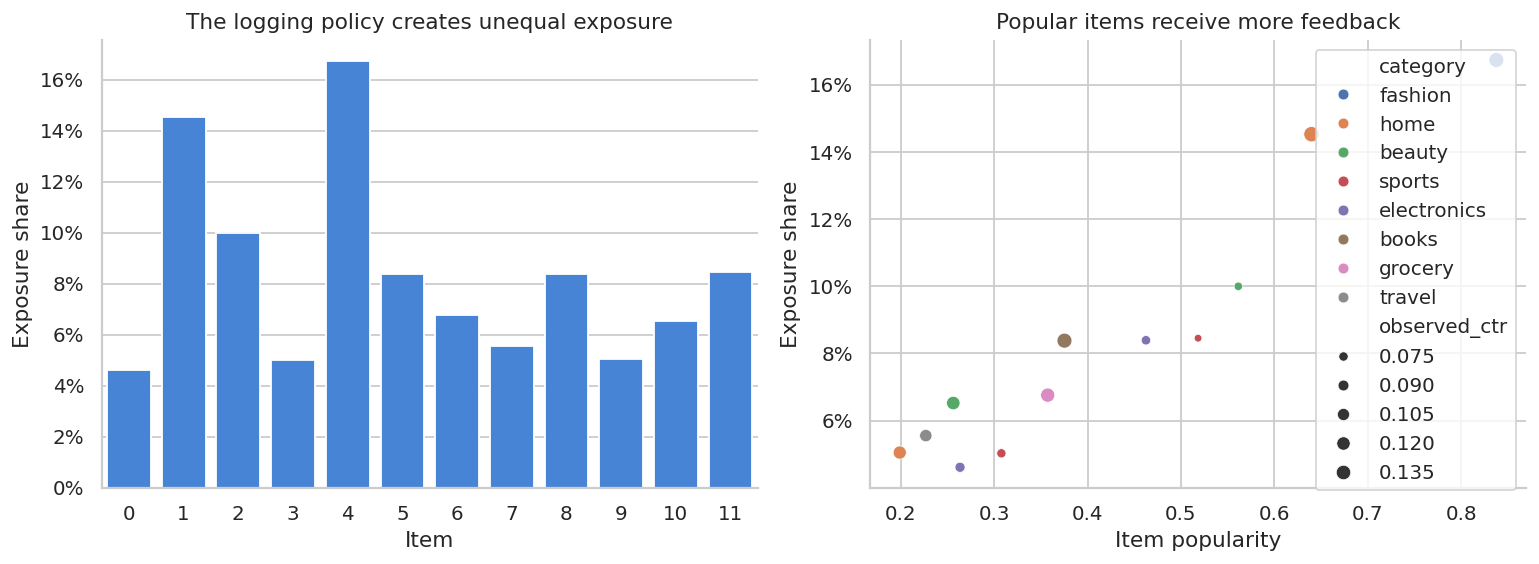

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=exposure, x="item_id", y="exposure_share", ax=axes[0], color="#2F80ED")
axes[0].set_title("The logging policy creates unequal exposure")
axes[0].set_xlabel("Item")
axes[0].set_ylabel("Exposure share")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

sns.scatterplot(data=exposure, x="popularity", y="exposure_share", size="observed_ctr", hue="category", ax=axes[1])
axes[1].set_title("Popular items receive more feedback")
axes[1].set_xlabel("Item popularity")
axes[1].set_ylabel("Exposure share")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

plt.tight_layout()
plt.show()

A recommender trained naively on this data will confuse exposure with preference. Items with more exposure have more clicks partly because they were shown more often.

relevance, exposure, clicks, and causal lift measure different things. A ranking change is defensible only when the logged exposure process supports the comparison.

## 5. Candidate Target Policies

We will evaluate three policies:

- **Logging policy:** the production policy that collected the data.
- **Click-max policy:** choose the item with the highest true click probability. In real life we would estimate this.
- **Profit-aware policy:** choose the item with the highest expected profit.

Because this is a simulation, we can compute the true value of each policy. In real data, we would not know these values.

In [8]:
click_policy_action = true_reward.argmax(axis=1)
profit_policy_action = true_profit.argmax(axis=1)

true_values = pd.DataFrame(
    [
        {
            "policy": "Logging policy",
            "true_click_value": np.mean(np.sum(behavior_probs * true_reward, axis=1)),
            "true_profit_value": np.mean(np.sum(behavior_probs * true_profit, axis=1)),
        },
        {
            "policy": "Click-max policy",
            "true_click_value": true_reward[np.arange(len(contexts)), click_policy_action].mean(),
            "true_profit_value": true_profit[np.arange(len(contexts)), click_policy_action].mean(),
        },
        {
            "policy": "Profit-aware policy",
            "true_click_value": true_reward[np.arange(len(contexts)), profit_policy_action].mean(),
            "true_profit_value": true_profit[np.arange(len(contexts)), profit_policy_action].mean(),
        },
    ]
)

display(styled_table(true_values, pct_cols=["true_click_value"], money_cols=["true_profit_value"]))

,policy,true_click_value,true_profit_value
0,Logging policy,11.08%,$2.68
1,Click-max policy,15.96%,$3.61
2,Profit-aware policy,14.33%,$4.54


Notice a common recommender tradeoff: the policy with the best click rate is not necessarily the policy with the best contribution profit.

relevance, exposure, clicks, and causal lift measure different things. A ranking change is defensible only when the logged exposure process supports the comparison.

## 6. Off-Policy Evaluation Estimators

Assume we have logs from a behavior policy $\mu(a\mid x)$ and want to estimate the value of target policy $\pi(a\mid x)$.

### Inverse Propensity Score

$$
\hat{V}_{IPS}(\pi) =
\frac{1}{n}\sum_{i=1}^n
\frac{\pi(A_i\mid X_i)}{\mu(A_i\mid X_i)}Y_i
$$

### Self-Normalized IPS

$$
\hat{V}_{SNIPS}(\pi) =
\frac{\sum_{i} w_i Y_i}{\sum_{i} w_i}
$$

where:

$$
w_i = \frac{\pi(A_i\mid X_i)}{\mu(A_i\mid X_i)}
$$

### Doubly Robust

Let $\hat{q}(x,a)$ estimate $E[Y\mid X=x,A=a]$.

$$
\hat{V}_{DR}(\pi)
=
\frac{1}{n}\sum_{i}
\left[
\sum_{a} \pi(a\mid X_i)\hat{q}(X_i,a)
+
\frac{\pi(A_i\mid X_i)}{\mu(A_i\mid X_i)}
\left(Y_i-\hat{q}(X_i,A_i)\right)
\right]
$$

The direct method uses the outcome model only. IPS uses randomization probabilities only. DR combines both.

In [9]:
# Fit the models for this section and assemble the estimates used in the discussion.
feature_cols = ["segment", "price_sensitivity", "novelty_preference", "purchase_intent", "item_id"]
categorical_cols = ["segment", "item_id"]
numeric_cols = ["price_sensitivity", "novelty_preference", "purchase_intent"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

reward_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=120,
                learning_rate=0.06,
                max_leaf_nodes=20,
                random_state=7,
            ),
        ),
    ]
)

reward_model.fit(logged[feature_cols], logged["click"])
logged["q_hat_logged"] = reward_model.predict_proba(logged[feature_cols])[:, 1]

auc = roc_auc_score(logged["click"], logged["q_hat_logged"])
print(f"Outcome model AUC on logged data: {auc:.3f}")

Outcome model AUC on logged data: 0.672


Here the method has to be judged against the design and the evidence. For ranking, clicks alone are a weak proxy. Exposure and logged propensities decide whether the comparison is credible.

In [10]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def predict_q_for_actions(contexts, catalog, model):
    """Generate q for actions predictions.
    
    Inputs:
    - `contexts`: user or session context DataFrame used by the recommender policy.
    - `catalog`: item catalog with item features used in the recommendation simulation.
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    Returns: predicted effects, rewards, or outcomes for the rows passed into the function."""
    blocks = []
    for item_id in catalog["item_id"]:
        temp = contexts.copy()
        temp["item_id"] = item_id
        blocks.append(model.predict_proba(temp[feature_cols])[:, 1])
    return np.column_stack(blocks)


q_hat_matrix = predict_q_for_actions(contexts, catalog, reward_model)


def ope_for_deterministic_policy(logged, target_actions, q_hat_matrix, outcome_col="click"):
    """Evaluate a deterministic recommendation policy from logged data.
    
    Inputs:
    - `logged`: logged-policy DataFrame with observed actions, propensities, rewards, and context features.
    - `target_actions`: target-policy action assigned to each logged row for off-policy evaluation.
    - `q_hat_matrix`: estimated expected reward for each row-action pair.
    - `outcome_col`: name of the outcome column used in the estimator or policy-value calculation.
    Returns: a pandas Series with direct-method, IPS, self-normalized IPS, and doubly robust estimates."""
    logged_action = logged["item_id"].to_numpy()
    mu = logged["propensity"].to_numpy()
    reward = logged[outcome_col].to_numpy()
    n = len(logged)
    match = logged_action == target_actions
    weights = match.astype(float) / mu

    ips = np.mean(weights * reward)
    snips = np.sum(weights * reward) / np.sum(weights)
    direct = q_hat_matrix[np.arange(n), target_actions].mean()
    dr = np.mean(
        q_hat_matrix[np.arange(n), target_actions]
        + weights * (reward - q_hat_matrix[np.arange(n), logged_action])
    )
    ess = (weights.sum() ** 2) / np.sum(weights**2)
    return {
        "direct_method": direct,
        "ips": ips,
        "snips": snips,
        "doubly_robust": dr,
        "match_rate": match.mean(),
        "mean_weight": weights.mean(),
        "max_weight": weights.max(),
        "effective_sample_size": ess,
    }


click_ope = ope_for_deterministic_policy(logged, click_policy_action, q_hat_matrix, outcome_col="click")
profit_ope_click_policy = ope_for_deterministic_policy(logged, click_policy_action, q_hat_matrix, outcome_col="profit")
profit_ope_profit_policy = ope_for_deterministic_policy(logged, profit_policy_action, q_hat_matrix, outcome_col="click")

ope_click_table = pd.DataFrame(
    [
        {
            "policy": "Click-max policy",
            "true_value": true_values.loc[true_values["policy"].eq("Click-max policy"), "true_click_value"].iloc[0],
            **click_ope,
        },
        {
            "policy": "Profit-aware policy",
            "true_value": true_values.loc[true_values["policy"].eq("Profit-aware policy"), "true_click_value"].iloc[0],
            **ope_for_deterministic_policy(logged, profit_policy_action, q_hat_matrix, outcome_col="click"),
        },
    ]
)

display(
    styled_table(
        ope_click_table[
            [
                "policy",
                "true_value",
                "direct_method",
                "ips",
                "snips",
                "doubly_robust",
                "match_rate",
                "effective_sample_size",
                "max_weight",
            ]
        ],
        pct_cols=["true_value", "direct_method", "ips", "snips", "doubly_robust", "match_rate"],
        num_cols=["effective_sample_size", "max_weight"],
    )
)

,policy,true_value,direct_method,ips,snips,doubly_robust,match_rate,effective_sample_size,max_weight
0,Click-max policy,15.96%,13.48%,16.20%,16.17%,16.15%,10.69%,"6,449.281",16.314
1,Profit-aware policy,14.33%,13.58%,14.16%,14.50%,14.50%,14.03%,"9,547.849",15.346


The target policies are deterministic, so only impressions where the logged item matches the target item contribute to IPS. If the match rate is low or weights are extreme, the offline estimate becomes fragile.

This is why mature recommender platforms log propensities and maintain exploration traffic.

In [11]:
# Assemble the summary table used to interpret the causal comparison.
def weight_diagnostics(logged, target_actions):
    """Summarize importance-weight behavior for a target ranking policy.
    
    Inputs:
    - `logged`: logged-policy DataFrame with observed actions, propensities, rewards, and context features.
    - `target_actions`: target-policy action assigned to each logged row for off-policy evaluation.
    Returns: a pandas Series with match rate, effective sample size, and high-weight diagnostics."""
    logged_action = logged["item_id"].to_numpy()
    weights = (logged_action == target_actions).astype(float) / logged["propensity"].to_numpy()
    positive = weights[weights > 0]
    return pd.DataFrame(
        {
            "metric": [
                "Match rate",
                "Mean positive weight",
                "95th percentile positive weight",
                "Max positive weight",
                "Effective sample size",
                "Effective sample share",
            ],
            "value": [
                (weights > 0).mean(),
                positive.mean(),
                np.quantile(positive, 0.95),
                positive.max(),
                (weights.sum() ** 2) / np.sum(weights**2),
                ((weights.sum() ** 2) / np.sum(weights**2)) / len(weights),
            ],
        }
    ), weights


diag_click, weights_click = weight_diagnostics(logged, click_policy_action)
diag_profit, weights_profit = weight_diagnostics(logged, profit_policy_action)

diag_click["policy"] = "Click-max policy"
diag_profit["policy"] = "Profit-aware policy"
weight_diag = pd.concat([diag_click, diag_profit], ignore_index=True)

display(weight_diag.pivot(index="metric", columns="policy", values="value").reset_index())

policy,metric,Click-max policy,Profit-aware policy
0,95th percentile positive weight,15.070827,10.061802
1,Effective sample share,0.092133,0.136398
2,Effective sample size,6449.281277,9547.848601
3,Match rate,0.106857,0.140343
4,Max positive weight,16.313727,15.346105
5,Mean positive weight,9.374935,6.958124


The point is to connect the number to the decision it supports. In recommender systems, the causal question lives inside the logging process and the exposure mechanism.

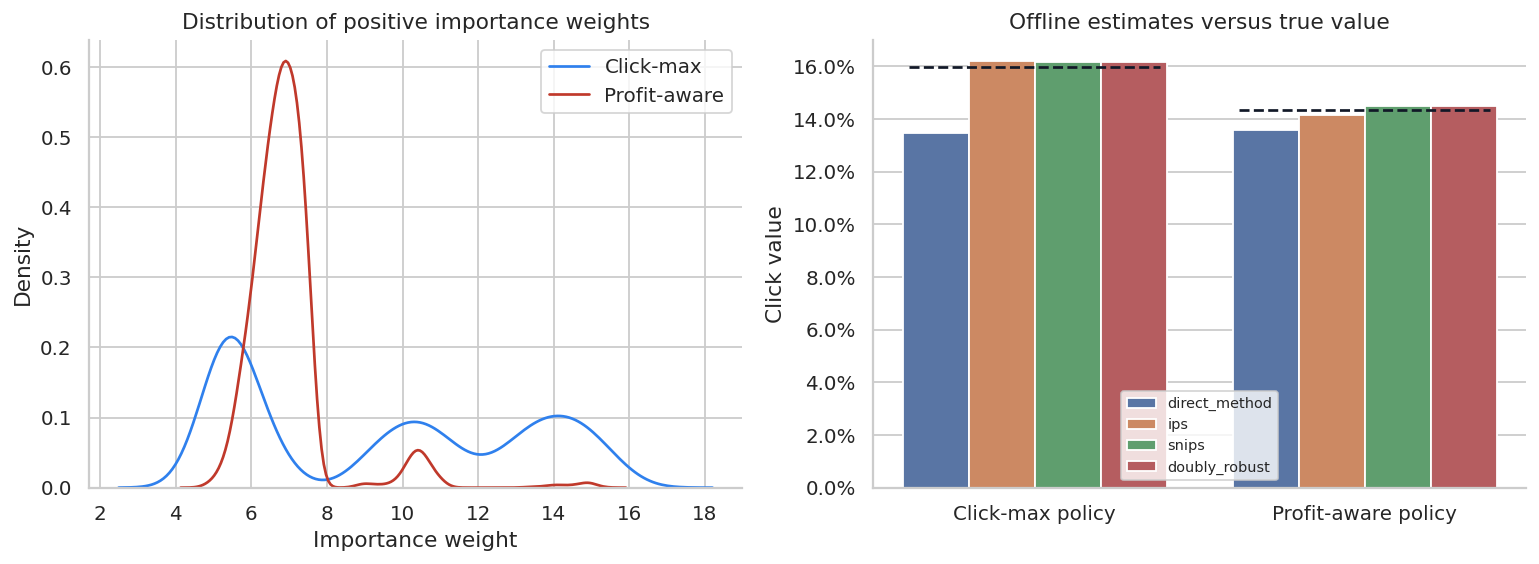

In [12]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for weights, label, color in [
    (weights_click, "Click-max", "#2F80ED"),
    (weights_profit, "Profit-aware", "#C0392B"),
]:
    positive = weights[weights > 0]
    sns.kdeplot(positive, ax=axes[0], label=label, color=color)
axes[0].set_title("Distribution of positive importance weights")
axes[0].set_xlabel("Importance weight")
axes[0].legend()

compare = ope_click_table.melt(
    id_vars=["policy", "true_value"],
    value_vars=["direct_method", "ips", "snips", "doubly_robust"],
    var_name="estimator",
    value_name="estimated_value",
)
sns.barplot(data=compare, x="policy", y="estimated_value", hue="estimator", ax=axes[1])
for i, policy in enumerate(compare["policy"].unique()):
    true_val = compare.loc[compare["policy"].eq(policy), "true_value"].iloc[0]
    axes[1].hlines(true_val, i - 0.38, i + 0.38, colors="#111827", linestyles="--")
axes[1].set_title("Offline estimates versus true value")
axes[1].set_xlabel("")
axes[1].set_ylabel("Click value")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.1f}%")
axes[1].legend(title="", fontsize=8)

plt.tight_layout()
plt.show()

This plot makes the central practical point:

- direct method can be biased if the reward model extrapolates poorly,
- IPS is unbiased under correct propensities and support, but can have high variance,
- SNIPS often reduces variance at the cost of some bias,
- doubly robust can be more stable when either the reward model or propensity logic is good enough.

None of these methods remove the need for an online experiment before major launch.

## 7. Profit-Aware Recommendation

Clicks are often not the real objective. An e-commerce system may care about contribution profit, long-term retention, customer satisfaction, inventory, or supplier fairness.

Here we estimate the value of the profit-aware policy using observed profit. We need a separate outcome model for profit if using DR on profit. For simplicity, we will compare IPS and SNIPS, then use an outcome model for expected profit.

In [13]:
# Fit the models for this section and assemble the estimates used in the discussion.
profit_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=100,
                learning_rate=0.06,
                max_leaf_nodes=18,
                random_state=11,
            ),
        ),
    ]
)

# Convert profit to a binary purchase proxy for model stability, then multiply by item margin in policy evaluation.
logged["purchase"] = (logged["profit"] > 0).astype(int)
profit_model.fit(logged[feature_cols], logged["purchase"])
q_purchase_matrix = predict_q_for_actions(contexts, catalog, profit_model)
q_profit_matrix = q_purchase_matrix * catalog["margin"].to_numpy()[None, :]


def ope_profit_for_policy(logged, target_actions, q_profit_matrix):
    """Estimate off-policy profit for a deterministic recommendation policy.
    
    Inputs:
    - `logged`: logged-policy DataFrame with observed actions, propensities, rewards, and context features.
    - `target_actions`: target-policy action assigned to each logged row for off-policy evaluation.
    - `q_profit_matrix`: estimated expected profit for each row-action pair.
    Returns: a pandas Series with direct-method, IPS, and doubly robust profit estimates."""
    logged_action = logged["item_id"].to_numpy()
    mu = logged["propensity"].to_numpy()
    reward = logged["profit"].to_numpy()
    n = len(logged)
    weights = (logged_action == target_actions).astype(float) / mu
    direct = q_profit_matrix[np.arange(n), target_actions].mean()
    ips = np.mean(weights * reward)
    snips = np.sum(weights * reward) / np.sum(weights)
    dr = np.mean(
        q_profit_matrix[np.arange(n), target_actions]
        + weights * (reward - q_profit_matrix[np.arange(n), logged_action])
    )
    return direct, ips, snips, dr


profit_eval_rows = []
for name, actions in [
    ("Click-max policy", click_policy_action),
    ("Profit-aware policy", profit_policy_action),
]:
    direct, ips, snips, dr = ope_profit_for_policy(logged, actions, q_profit_matrix)
    true_profit_value = true_profit[np.arange(len(contexts)), actions].mean()
    profit_eval_rows.append(
        {
            "policy": name,
            "true_profit_value": true_profit_value,
            "direct_method": direct,
            "ips": ips,
            "snips": snips,
            "doubly_robust": dr,
        }
    )

profit_eval = pd.DataFrame(profit_eval_rows)

display(
    styled_table(
        profit_eval,
        money_cols=["true_profit_value", "direct_method", "ips", "snips", "doubly_robust"],
    )
)

,policy,true_profit_value,direct_method,ips,snips,doubly_robust
0,Click-max policy,$3.61,$3.05,$3.61,$3.60,$3.61
1,Profit-aware policy,$4.54,$4.35,$4.50,$4.61,$4.61


A ranking policy should be evaluated against the business objective, beyond the easiest label. If click-max increases clicks and shifts traffic toward low-margin items, it may look good in a product analytics dashboard while hurting contribution profit.

## 8. Position Bias in Ranked Lists

Now move from one top-slot recommendation to a ranked list.

In a ranked interface, an item can receive more clicks because it is more relevant or because it was placed higher. Let:

$$
C_{ij} = E_{ij} \cdot R_{ij}
$$

where:

- $C_{ij}$ is whether user $i$ clicked item $j$,
- $E_{ij}$ is whether the user examined the position,
- $R_{ij}$ is whether the item was relevant enough to click if examined.

If examination probability differs by rank, naive click-through rate is a biased relevance label.

In [14]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_ranked_logs(contexts, catalog, true_reward, top_k=5, n_sessions=35_000, seed=55):
    """Simulate the ranked logs data-generating process.
    
    Inputs:
    - `contexts`: user or session context DataFrame used by the recommender policy.
    - `catalog`: item catalog with item features used in the recommendation simulation.
    - `true_reward`: matrix of simulated true expected rewards for every context-item pair.
    - `top_k`: number of ranked items shown in each recommendation session.
    - `n_sessions`: number of recommendation or ranking sessions to simulate.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    local_rng = np.random.default_rng(seed)
    subset_idx = local_rng.choice(len(contexts), size=n_sessions, replace=False)
    ctx = contexts.iloc[subset_idx].reset_index(drop=True)
    rewards = true_reward[subset_idx]

    # Production ranker favors popularity and relevance.
    rank_score = 1.6 * rewards + 0.85 * catalog["popularity"].to_numpy()[None, :]
    rankings = np.argsort(-rank_score, axis=1)[:, :top_k]
    exam_prob_by_position = np.array([0.90, 0.62, 0.43, 0.30, 0.20])

    rows = []
    for i in range(n_sessions):
        for pos in range(top_k):
            item = rankings[i, pos]
            relevance = rewards[i, item]
            exam_prob = exam_prob_by_position[pos]
            click_prob = exam_prob * relevance
            click = local_rng.binomial(1, click_prob)
            rows.append(
                {
                    "session_id": i,
                    "segment": ctx.loc[i, "segment"],
                    "position": pos + 1,
                    "item_id": item,
                    "examination_prob": exam_prob,
                    "true_relevance": relevance,
                    "click": click,
                }
            )
    return pd.DataFrame(rows)


rank_logs = simulate_ranked_logs(contexts, catalog, true_reward)

display(rank_logs.head())
print(f"Rows: {len(rank_logs):,}")
print(f"Sessions: {rank_logs['session_id'].nunique():,}")

,session_id,segment,position,item_id,examination_prob,true_relevance,click
0,0,loyalist,1,4,0.90,0.110160,0
1,0,loyalist,2,1,0.62,0.117660,0
2,0,loyalist,3,2,0.43,0.058435,0
3,0,loyalist,4,5,0.30,0.147432,0
4,0,loyalist,5,11,0.20,0.048940,0


Rows: 175,000
Sessions: 35,000


Here the example becomes operational. A ranking policy is defensible only when relevance, exposure, reward, and support are all visible.

In [15]:
position_summary = (
    rank_logs.groupby("position")
    .agg(
        rows=("click", "size"),
        observed_ctr=("click", "mean"),
        mean_true_relevance=("true_relevance", "mean"),
        examination_prob=("examination_prob", "mean"),
    )
    .reset_index()
)

display(styled_table(position_summary, pct_cols=["observed_ctr", "mean_true_relevance", "examination_prob"]))

,position,rows,observed_ctr,mean_true_relevance,examination_prob
0,1,35000,11.98%,13.38%,90.00%
1,2,35000,8.77%,14.56%,62.00%
2,3,35000,4.50%,10.42%,43.00%
3,4,35000,2.63%,9.10%,30.00%
4,5,35000,1.79%,8.60%,20.00%


This output should make the next modeling choice easier to defend. For ranking, clicks alone are a weak proxy. Exposure and logged propensities decide whether the comparison is credible.

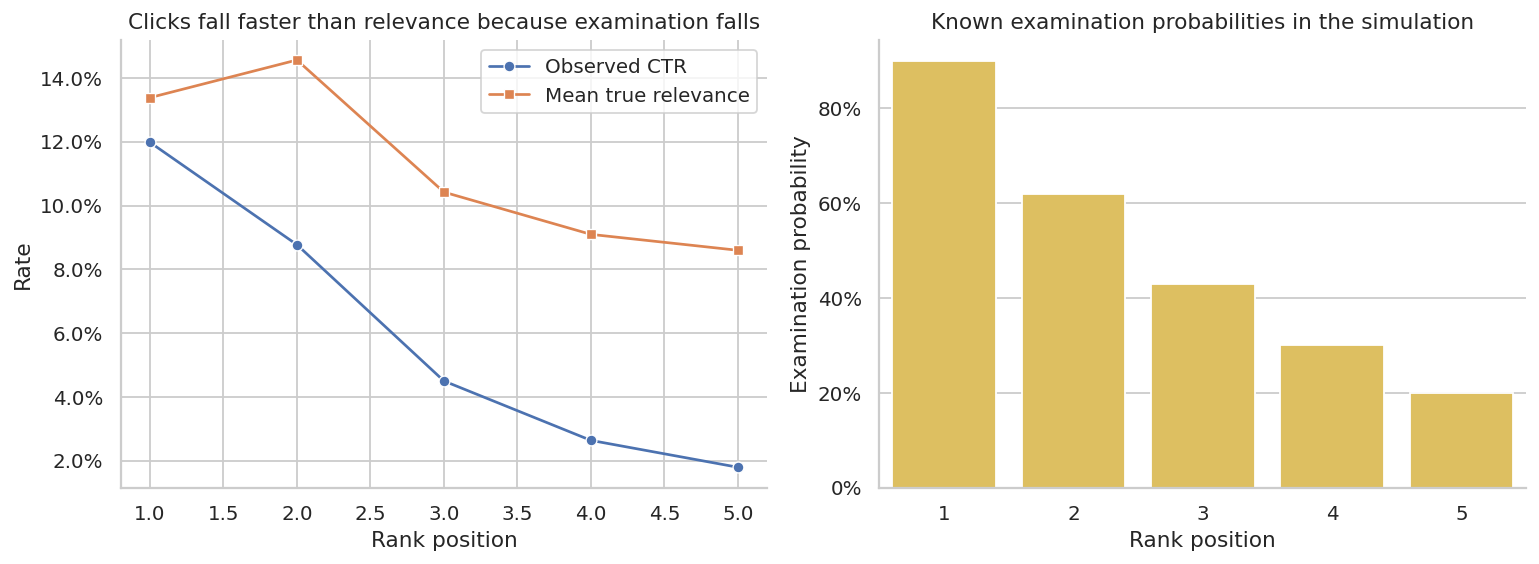

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.lineplot(data=position_summary, x="position", y="observed_ctr", marker="o", ax=axes[0], label="Observed CTR")
sns.lineplot(data=position_summary, x="position", y="mean_true_relevance", marker="s", ax=axes[0], label="Mean true relevance")
axes[0].set_title("Clicks fall faster than relevance because examination falls")
axes[0].set_xlabel("Rank position")
axes[0].set_ylabel("Rate")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.1f}%")
axes[0].legend()

sns.barplot(data=position_summary, x="position", y="examination_prob", ax=axes[1], color="#F2C94C")
axes[1].set_title("Known examination probabilities in the simulation")
axes[1].set_xlabel("Rank position")
axes[1].set_ylabel("Examination probability")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

plt.tight_layout()
plt.show()

The top position gets many more clicks partly because it is examined more often. Treating clicks as direct relevance labels would over-credit higher positions and under-credit lower positions.

relevance, exposure, clicks, and causal lift measure different things. A ranking change is defensible only when the logged exposure process supports the comparison.

In [17]:
# Assemble the summary table used to interpret the causal comparison.
item_rank_summary = (
    rank_logs.groupby("item_id")
    .agg(
        exposures=("click", "size"),
        avg_position=("position", "mean"),
        naive_ctr=("click", "mean"),
        ips_relevance_estimate=("click", lambda x: np.nan),
        true_relevance=("true_relevance", "mean"),
    )
    .reset_index()
)

ips_by_item = (
    rank_logs.assign(weighted_click=lambda d: d["click"] / d["examination_prob"])
    .groupby("item_id")
    .agg(ips_relevance_estimate=("weighted_click", "mean"))
    .reset_index()
)
item_rank_summary = item_rank_summary.drop(columns=["ips_relevance_estimate"]).merge(ips_by_item, on="item_id")
item_rank_summary = item_rank_summary.merge(catalog[["item_id", "category", "popularity"]], on="item_id")

display(
    styled_table(
        item_rank_summary.sort_values("avg_position"),
        pct_cols=["naive_ctr", "ips_relevance_estimate", "true_relevance"],
        num_cols=["avg_position", "popularity"],
    )
)

,item_id,exposures,avg_position,naive_ctr,true_relevance,ips_relevance_estimate,category,popularity
2,4,35000,1.000,11.98%,13.38%,13.31%,fashion,0.838
0,1,35000,2.000,8.77%,14.56%,14.15%,home,0.640
1,2,34821,3.459,2.25%,6.59%,6.18%,beauty,0.561
3,5,15269,3.856,6.33%,18.55%,18.58%,books,0.375
4,6,10023,4.119,4.76%,14.50%,14.82%,grocery,0.357
7,11,31535,4.316,1.88%,6.48%,6.65%,sports,0.518
5,8,13301,4.739,2.28%,9.04%,9.74%,electronics,0.463
6,10,51,5.000,1.96%,27.50%,9.80%,beauty,0.256


The result is most useful when it shapes the next action. In recommender systems, the causal question lives inside the logging process and the exposure mechanism.

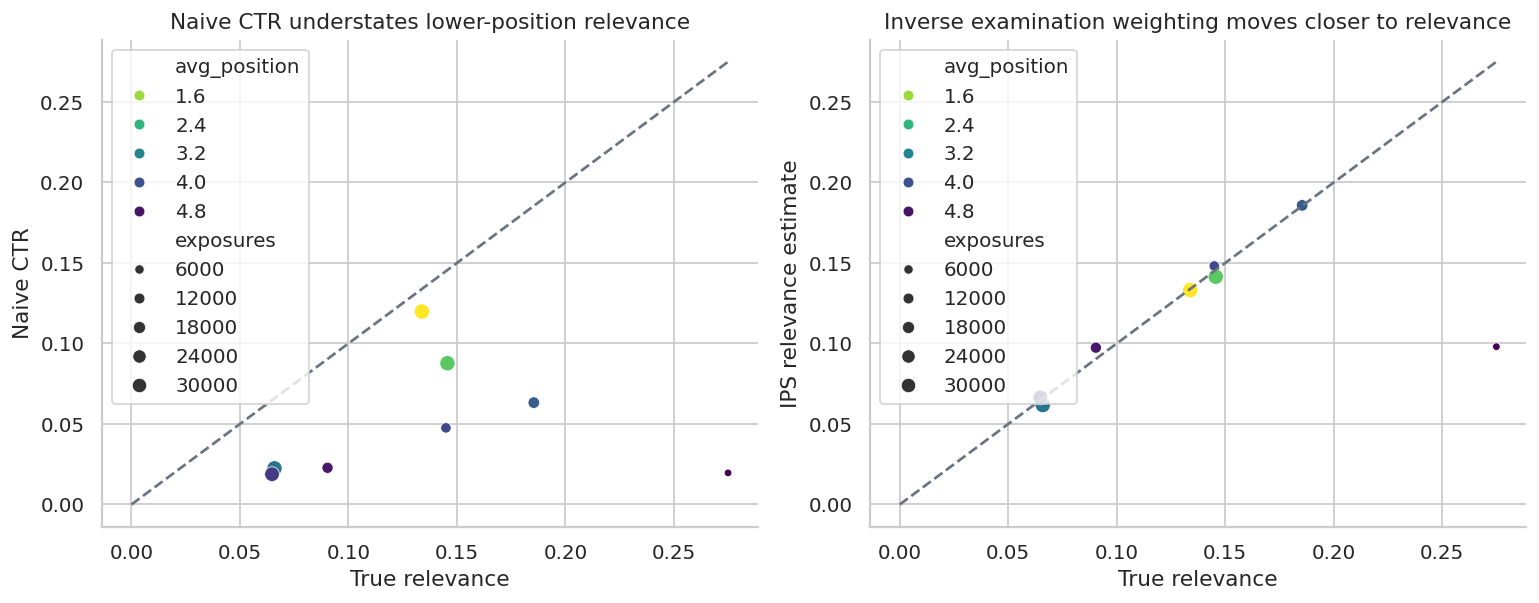

In [18]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(
    data=item_rank_summary,
    x="true_relevance",
    y="naive_ctr",
    size="exposures",
    hue="avg_position",
    palette="viridis_r",
    ax=axes[0],
)
axes[0].plot([0, item_rank_summary["true_relevance"].max()], [0, item_rank_summary["true_relevance"].max()], "--", color="#6B7280")
axes[0].set_title("Naive CTR understates lower-position relevance")
axes[0].set_xlabel("True relevance")
axes[0].set_ylabel("Naive CTR")

sns.scatterplot(
    data=item_rank_summary,
    x="true_relevance",
    y="ips_relevance_estimate",
    size="exposures",
    hue="avg_position",
    palette="viridis_r",
    ax=axes[1],
)
axes[1].plot([0, item_rank_summary["true_relevance"].max()], [0, item_rank_summary["true_relevance"].max()], "--", color="#6B7280")
axes[1].set_title("Inverse examination weighting moves closer to relevance")
axes[1].set_xlabel("True relevance")
axes[1].set_ylabel("IPS relevance estimate")

plt.tight_layout()
plt.show()

This simple correction uses known examination propensities. In real systems, propensities are often estimated from randomized swaps, interleaving experiments, eye-tracking studies, or click models. If the examination model is wrong, the correction can still be biased.

## 9. Feedback Loops and Exposure Concentration

Recommendation systems can create their own evidence.

If the next model trains on clicks from the current model, then exposed items get more labels and hidden items remain uncertain. A popularity-based retraining loop can concentrate exposure over time.

In [19]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_feedback_loop(catalog, rounds=18, impressions_per_round=8_000, seed=70):
    """Simulate the feedback loop data-generating process.
    
    Inputs:
    - `catalog`: item catalog with item features used in the recommendation simulation.
    - `rounds`: number of feedback-loop rounds to simulate.
    - `impressions_per_round`: number of impressions generated in each feedback-loop round.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    local_rng = np.random.default_rng(seed)
    item_quality = expit(catalog["quality"].to_numpy())
    popularity_score = catalog["popularity"].to_numpy().copy()
    records = []

    for t in range(rounds):
        score = 0.35 * item_quality + 0.65 * popularity_score
        probs = softmax(score / 0.20)
        shown = local_rng.choice(len(catalog), size=impressions_per_round, p=probs)
        click_prob = item_quality[shown] * 0.12
        clicks = local_rng.binomial(1, click_prob)

        counts = np.bincount(shown, minlength=len(catalog))
        click_counts = np.bincount(shown, weights=clicks, minlength=len(catalog))

        # Update popularity using observed clicks.
        popularity_score = 0.88 * popularity_score + 0.12 * (click_counts + 1) / (counts + 10)

        exposure_share = counts / counts.sum()
        top_item_share = exposure_share.max()
        herfindahl = np.sum(exposure_share**2)
        avg_quality_shown = np.average(item_quality, weights=exposure_share)
        records.append(
            {
                "round": t,
                "top_item_exposure_share": top_item_share,
                "exposure_concentration_hhi": herfindahl,
                "avg_quality_shown": avg_quality_shown,
            }
        )

    return pd.DataFrame(records)


feedback = simulate_feedback_loop(catalog)
display(feedback.head())

,round,top_item_exposure_share,exposure_concentration_hhi,avg_quality_shown
0,0,0.319000,0.157876,0.552139
1,1,0.268500,0.135100,0.550626
2,2,0.250375,0.125967,0.549092
3,3,0.228625,0.116758,0.544836
4,4,0.213250,0.110587,0.545068


This is a checkpoint for the design and the estimate together. A ranking policy is defensible only when relevance, exposure, reward, and support are all visible.

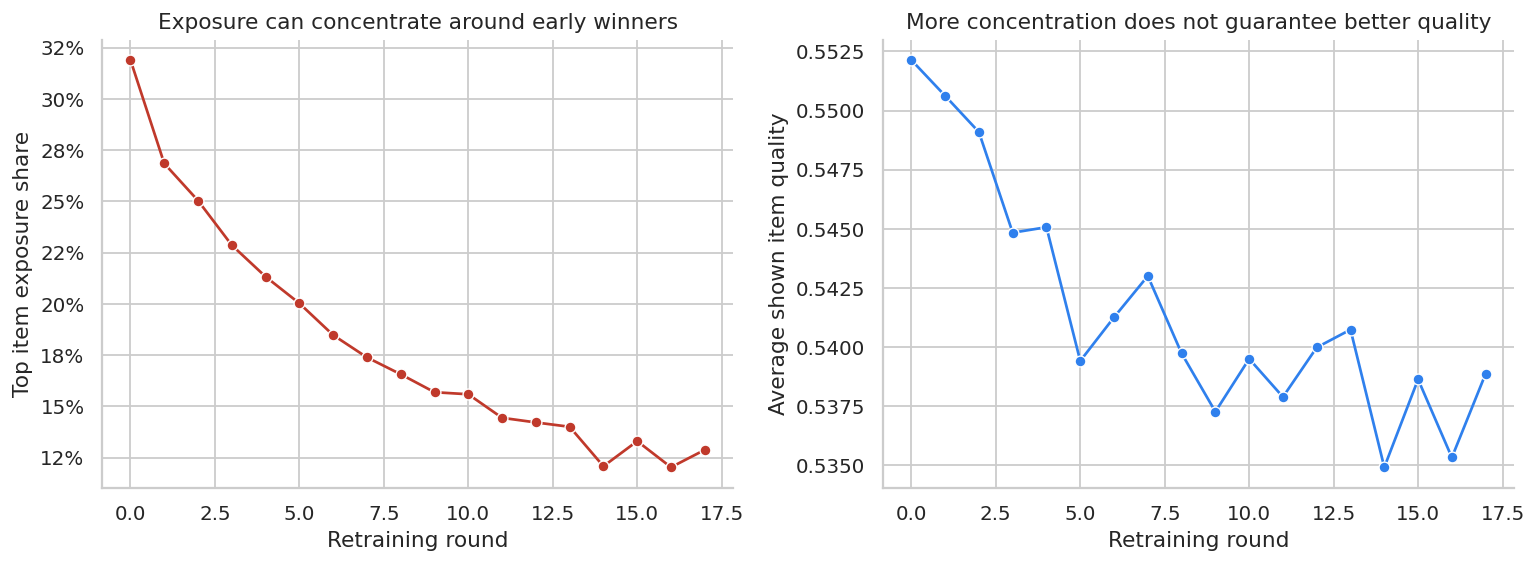

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.lineplot(data=feedback, x="round", y="top_item_exposure_share", marker="o", ax=axes[0], color="#C0392B")
axes[0].set_title("Exposure can concentrate around early winners")
axes[0].set_xlabel("Retraining round")
axes[0].set_ylabel("Top item exposure share")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

sns.lineplot(data=feedback, x="round", y="avg_quality_shown", marker="o", ax=axes[1], color="#2F80ED")
axes[1].set_title("More concentration does not guarantee better quality")
axes[1].set_xlabel("Retraining round")
axes[1].set_ylabel("Average shown item quality")

plt.tight_layout()
plt.show()

Feedback loops are not solved by better predictive modeling alone. They require exploration, counterfactual evaluation, guardrails, and sometimes explicit diversity constraints.

relevance, exposure, clicks, and causal lift measure different things. A ranking change is defensible only when the logged exposure process supports the comparison.

## 10. Online Experiment Readout

Offline OPE is a screening tool. For a meaningful product launch, the final answer should come from an online experiment when feasible.

We will simulate a simple A/B test comparing the logging policy with the profit-aware policy.

In [21]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_ab_test(contexts, catalog, true_reward, true_profit, n=50_000, seed=88):
    """Simulate the ab test data-generating process.
    
    Inputs:
    - `contexts`: user or session context DataFrame used by the recommender policy.
    - `catalog`: item catalog with item features used in the recommendation simulation.
    - `true_reward`: matrix of simulated true expected rewards for every context-item pair.
    - `true_profit`: matrix of simulated true expected profit for every context-item pair.
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    local_rng = np.random.default_rng(seed)
    idx = local_rng.choice(len(contexts), n, replace=False)
    group = local_rng.binomial(1, 0.5, size=n)
    behavior_probs_test = behavior_probs[idx]
    logging_actions = np.array([local_rng.choice(len(catalog), p=p) for p in behavior_probs_test])
    target_actions = true_profit[idx].argmax(axis=1)
    actions = np.where(group == 1, target_actions, logging_actions)
    click_prob = true_reward[idx, actions]
    clicks = local_rng.binomial(1, click_prob)
    profit = clicks * catalog.loc[actions, "margin"].to_numpy()
    novelty = catalog.loc[actions, "novelty"].to_numpy()
    category = catalog.loc[actions, "category"].to_numpy()
    return pd.DataFrame(
        {
            "group": np.where(group == 1, "Profit-aware target", "Logging control"),
            "item_id": actions,
            "category": category,
            "click": clicks,
            "profit": profit,
            "novelty": novelty,
        }
    )


ab = simulate_ab_test(contexts, catalog, true_reward, true_profit)

ab_summary = (
    ab.groupby("group")
    .agg(
        impressions=("click", "size"),
        click_rate=("click", "mean"),
        profit_per_impression=("profit", "mean"),
        avg_novelty=("novelty", "mean"),
        category_diversity=("category", lambda x: 1 - np.sum((x.value_counts(normalize=True) ** 2))),
    )
    .reset_index()
)

display(styled_table(ab_summary, pct_cols=["click_rate"], money_cols=["profit_per_impression"], num_cols=["avg_novelty", "category_diversity"]))

,group,impressions,click_rate,profit_per_impression,avg_novelty,category_diversity
0,Logging control,24833,11.15%,$2.67,0.434,0.856
1,Profit-aware target,25167,14.50%,$4.59,0.755,0.177


The result matters because it changes what we would audit or do next. For ranking, clicks alone are a weak proxy. Exposure and logged propensities decide whether the comparison is credible.

In [22]:
def diff_in_means_ci(df, outcome, treatment_label="Profit-aware target", control_label="Logging control"):
    """Compute diff in means ci for the recommendation systems and ranking example.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment_label`: label identifying the treated group in a comparison table.
    - `control_label`: label identifying the control or baseline group in a comparison table.
    Returns: a treatment-control difference with its uncertainty summary."""
    t = df.loc[df["group"].eq(treatment_label), outcome].to_numpy()
    c = df.loc[df["group"].eq(control_label), outcome].to_numpy()
    diff = t.mean() - c.mean()
    se = np.sqrt(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c))
    return diff, diff - 1.96 * se, diff + 1.96 * se


ab_effects = []
for outcome in ["click", "profit", "novelty"]:
    diff, lo, hi = diff_in_means_ci(ab, outcome)
    ab_effects.append({"outcome": outcome, "lift": diff, "ci_low": lo, "ci_high": hi})
ab_effects = pd.DataFrame(ab_effects)

display(ab_effects)

,outcome,lift,ci_low,ci_high
0,click,0.033407,0.027554,0.039259
1,profit,1.920929,1.749178,2.092681
2,novelty,0.320962,0.317516,0.324408


At this point the lecture becomes practical. In recommender systems, the causal question lives inside the logging process and the exposure mechanism.

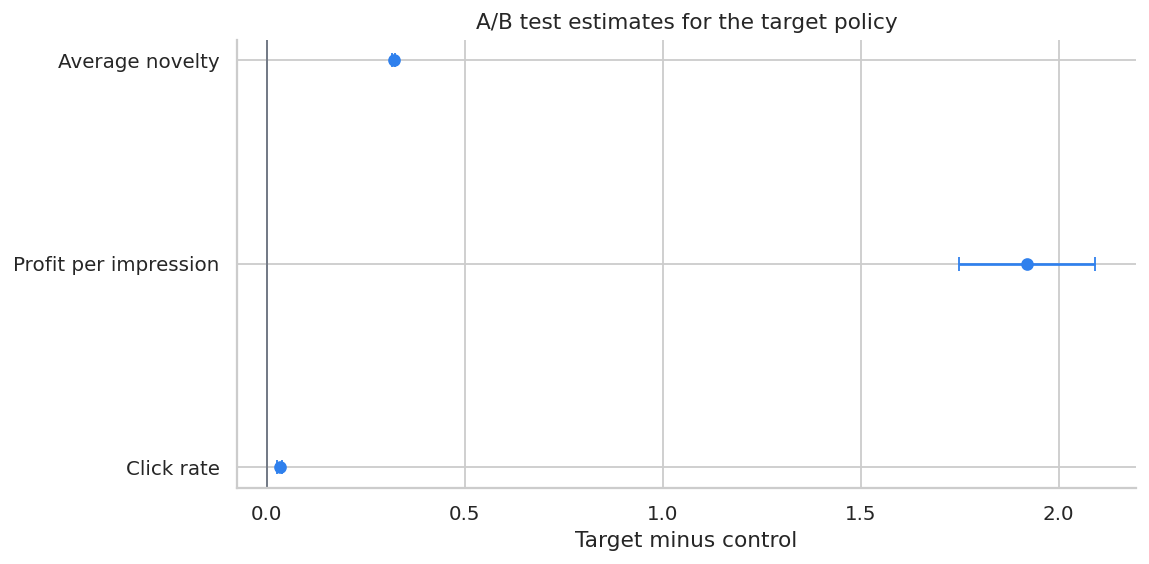

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_effects = ab_effects.copy()
plot_effects["outcome"] = plot_effects["outcome"].map(
    {"click": "Click rate", "profit": "Profit per impression", "novelty": "Average novelty"}
)
plot_effects["y"] = np.arange(len(plot_effects))
ax.errorbar(
    plot_effects["lift"],
    plot_effects["y"],
    xerr=[plot_effects["lift"] - plot_effects["ci_low"], plot_effects["ci_high"] - plot_effects["lift"]],
    fmt="o",
    color="#2F80ED",
    capsize=4,
)
ax.axvline(0, color="#6B7280", linewidth=1)
ax.set_yticks(plot_effects["y"])
ax.set_yticklabels(plot_effects["outcome"])
ax.set_title("A/B test estimates for the target policy")
ax.set_xlabel("Target minus control")
plt.tight_layout()
plt.show()

This A/B test directly estimates the policy effect in the deployment environment. Offline estimates helped decide whether the policy was worth testing; the online test provides the launch evidence.

relevance, exposure, clicks, and causal lift measure different things. A ranking change is defensible only when the logged exposure process supports the comparison.

## 11. Practical Diagnostics

A recommendation policy should not move from offline analysis to launch without diagnostics.

In [24]:
# Fit the models for this section and assemble the estimates used in the discussion.
diagnostics = pd.DataFrame(
    [
        {
            "diagnostic": "Propensity logging",
            "question": "Do logs contain the exact probability of the shown action?",
            "failure mode": "IPS and DR cannot be trusted without behavior propensities.",
        },
        {
            "diagnostic": "Common support",
            "question": "Does the logging policy sometimes choose actions the target policy would choose?",
            "failure mode": "Offline estimates extrapolate into unsupported regions.",
        },
        {
            "diagnostic": "Effective sample size",
            "question": "How many weighted observations really identify the target policy?",
            "failure mode": "A large log can become a small effective experiment.",
        },
        {
            "diagnostic": "Weight tails",
            "question": "Are a few impressions carrying most of the IPS estimate?",
            "failure mode": "High variance and unstable conclusions.",
        },
        {
            "diagnostic": "Position bias",
            "question": "Can we separate examination from relevance?",
            "failure mode": "Top positions look better just because users see them.",
        },
        {
            "diagnostic": "Objective alignment",
            "question": "Are we optimizing clicks, profit, retention, satisfaction, or long-term value?",
            "failure mode": "The model improves an easy metric while harming the real objective.",
        },
        {
            "diagnostic": "Guardrails",
            "question": "What happens to diversity, creator exposure, inventory, latency, and complaint rate?",
            "failure mode": "The recommender wins the primary metric but damages the ecosystem.",
        },
    ]
)

display(diagnostics)

,diagnostic,question,failure mode
0,Propensity logging,Do logs contain the exact probability of the s...,IPS and DR cannot be trusted without behavior ...
1,Common support,Does the logging policy sometimes choose actio...,Offline estimates extrapolate into unsupported...
2,Effective sample size,How many weighted observations really identify...,A large log can become a small effective exper...
3,Weight tails,Are a few impressions carrying most of the IPS...,High variance and unstable conclusions.
4,Position bias,Can we separate examination from relevance?,Top positions look better just because users s...
5,Objective alignment,"Are we optimizing clicks, profit, retention, s...",The model improves an easy metric while harmin...
6,Guardrails,"What happens to diversity, creator exposure, i...",The recommender wins the primary metric but da...


This output links the method back to the decision. A ranking policy is defensible only when relevance, exposure, reward, and support are all visible.

## 12. Decision Memo Template

Below is a compact readout that combines offline OPE with the online experiment recommendation.

In [25]:
profit_row = profit_eval.loc[profit_eval["policy"].eq("Profit-aware policy")].iloc[0]
logging_profit = true_values.loc[true_values["policy"].eq("Logging policy"), "true_profit_value"].iloc[0]
offline_dr_lift = profit_row["doubly_robust"] - logging_profit
ab_profit = ab_effects.loc[ab_effects["outcome"].eq("profit")].iloc[0]
ess_profit = weight_diagnostics(logged, profit_policy_action)[0].query("metric == 'Effective sample size'")["value"].iloc[0]

memo = f'''
### Recommendation Policy Readout

**Decision:** Whether to advance the profit-aware recommender from offline evaluation to broader online testing.

**Current policy:** Production logging policy with stochastic exploration.

**Candidate policy:** Profit-aware top-slot recommender.

**Offline OPE:** Doubly robust estimated profit value for the candidate is {dollars(profit_row["doubly_robust"], 3)} per impression.

**Estimated offline lift versus logging policy:** {dollars(offline_dr_lift, 3)} per impression.

**Support diagnostic:** Effective sample size for the candidate policy is {ess_profit:,.0f} impressions out of {len(logged):,} logged impressions.

**Online experiment result:** A/B profit lift is {dollars(ab_profit["lift"], 3)} per impression with 95% CI [{dollars(ab_profit["ci_low"], 3)}, {dollars(ab_profit["ci_high"], 3)}].

**Recommendation:** Continue staged rollout if guardrails remain stable; keep exploration traffic active so future candidate policies remain evaluable.

**Caveats:** Monitor diversity, item exposure concentration, customer satisfaction, long-term retention, and support gaps for new or rarely shown items.
'''

display(Markdown(memo))


### Recommendation Policy Readout

**Decision:** Whether to advance the profit-aware recommender from offline evaluation to broader online testing.

**Current policy:** Production logging policy with stochastic exploration.

**Candidate policy:** Profit-aware top-slot recommender.

**Offline OPE:** Doubly robust estimated profit value for the candidate is $4.615 per impression.

**Estimated offline lift versus logging policy:** $1.938 per impression.

**Support diagnostic:** Effective sample size for the candidate policy is 9,548 impressions out of 70,000 logged impressions.

**Online experiment result:** A/B profit lift is $1.921 per impression with 95% CI [$1.749, $2.093].

**Recommendation:** Continue staged rollout if guardrails remain stable; keep exploration traffic active so future candidate policies remain evaluable.

**Caveats:** Monitor diversity, item exposure concentration, customer satisfaction, long-term retention, and support gaps for new or rarely shown items.


A senior readout should separate three claims:

1. **Offline evidence:** the candidate looks promising under OPE.
2. **Identification risk:** support, propensities, position bias, and reward modeling are plausible but imperfect.
3. **Deployment decision:** online experimentation and guardrails decide launch.

## 13. Practical Workflow

A strong causal recommender workflow usually looks like this:

1. Define the decision policy and the business objective.
2. Log action propensities for every recommendation or ranking.
3. Maintain exploration traffic so future policies have support.
4. Store context, candidate set, action, position, layout, propensity, and reward.
5. Estimate direct, IPS, SNIPS, and DR values.
6. Report match rate, weight distribution, and effective sample size.
7. Correct ranking feedback for position or examination bias.
8. Check guardrails: diversity, fairness, inventory, latency, long-term retention.
9. Use OPE as a screen, not a final launch decision.
10. Validate with an online experiment before broad rollout.

## Hands-On Extensions

Try extending this notebook in the following ways:

- Replace the deterministic target policies with stochastic target policies.
- Add a slate policy that recommends three items at once.
- Estimate propensities when known logged propensities are unavailable.
- Add delayed rewards such as 7-day retention or repeat purchase.
- Add a constraint that limits exposure concentration for any one item.
- Compare IPS with clipped IPS and SWITCH-style estimators.
- Train a CATE model to personalize exploration rates.

## Key Takeaways

- Recommender systems create the data used to train and evaluate future recommenders.
- Historical clicks are biased by selection, position, trust, and feedback loops.
- Policy value is a causal estimand: what reward would happen under a target policy?
- IPS uses logged propensities to correct distribution mismatch.
- SNIPS and DR can improve finite-sample stability, but they require diagnostics.
- Position bias means click probability is not relevance probability.
- Exploration is an asset because it creates support for future policy evaluation.
- Offline OPE should screen policies before online experimentation, not replace A/B tests.

## References

Jagerman, R., & de Rijke, M. (2020). Accelerated convergence for counterfactual learning to rank. *Proceedings of the 43rd International ACM SIGIR Conference on Research and Development in Information Retrieval*, 469-478. https://doi.org/10.1145/3397271.3401069

Joachims, T., & Swaminathan, A. (2016). Counterfactual evaluation and learning for search, recommendation and ad placement. *Proceedings of the 39th International ACM SIGIR Conference on Research and Development in Information Retrieval*, 1199-1201. https://doi.org/10.1145/2911451.2914803

Kiyohara, H., Saito, Y., & Matsuhiro, T. (2022). Doubly robust off-policy evaluation for ranking policies under the cascade behavior model. *Proceedings of the Fifteenth ACM International Conference on Web Search and Data Mining*, 487-497. https://doi.org/10.1145/3488560.3498380

Saito, Y., Aihara, S., Matsutani, M., & Narita, Y. (2020). Open bandit dataset and pipeline: Towards realistic and reproducible off-policy evaluation. *arXiv*. https://doi.org/10.48550/arxiv.2008.07146

Saito, Y., & Joachims, T. (2022). Off-policy evaluation for large action spaces via embeddings. *arXiv*. https://doi.org/10.48550/arxiv.2202.06317

Su, Y., Dimakopoulou, M., Krishnamurthy, A., & Dudík, M. (2019). Doubly robust off-policy evaluation with shrinkage. *arXiv*. https://doi.org/10.48550/arxiv.1907.09623

Vardasbi, A., Oosterhuis, H., & de Rijke, M. (2020). When inverse propensity scoring does not work. *Proceedings of the 29th ACM International Conference on Information & Knowledge Management*, 1475-1484. https://doi.org/10.1145/3340531.3412031
